# UNIVERSIDAD AUTÓNOMA DE AGUASCALIENTES
## Departamento: Ciencias de la Computación
## Carrera: Ingeniería en Computación Inteligente

**Curso:** Machine y Deep Learning  
**Maestro:** Dr. Francisco Javier Luna Rosas  
**Alumno:** Carlos Daniel Torres Macias
**Semestre:** Enero-Junio del 2026

---

# Práctica No. 34 – Test de Normalidad y Suavizado de Series de Tiempo (Python)

En esta práctica se aplican **test de normalidad** y técnicas de **suavizado** a las 5 series de tiempo reales obtenidas en la Práctica 32 (Yahoo Finance).

Lo primero que se le debe hacer a una serie de tiempo es el **test de normalidad de los residuos (diferencias)**, que significa verificar si los datos de las diferencias siguen una distribución normal. Posteriormente se aplican **filtros de suavizado** para reducir el ruido y revelar la tendencia subyacente.

| # | Serie de Tiempo | Ticker |
|---|----------------|--------|
| 1 | Apple Inc.      | AAPL   |
| 2 | Tesla Inc.      | TSLA   |
| 3 | Bitcoin         | BTC-USD|
| 4 | Tipo de cambio USD/MXN | MXN=X |
| 5 | Petróleo Crudo WTI | CL=F |


## Paso 1: Instalación e Importación de Librerías

In [2]:
# Instalación de dependencias necesarias
!pip install yfinance scipy --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import shapiro, kstest, jarque_bera, norm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Paso 2: Descarga de las 5 Series de Tiempo (Práctica 32)

In [3]:
# Período de análisis: mismo que Práctica 32
inicio = '2023-01-01'
fin    = '2025-01-01'

series = {
    'AAPL'   : 'Apple Inc. (AAPL)',
    'TSLA'   : 'Tesla Inc. (TSLA)',
    'BTC-USD': 'Bitcoin (BTC-USD)',
    'MXN=X'  : 'USD/MXN Tipo de Cambio',
    'CL=F'   : 'Petróleo Crudo (WTI Futures)'
}

datos = {}
for ticker, nombre in series.items():
    df = yf.download(ticker, start=inicio, end=fin, progress=False, auto_adjust=True)
    close = df['Close'].squeeze()
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    close.name = ticker
    datos[ticker] = close.dropna()
    print(f'{nombre}: {len(datos[ticker])} observaciones')

print('\nDescarga completada.')


Apple Inc. (AAPL): 502 observaciones
Tesla Inc. (TSLA): 502 observaciones
Bitcoin (BTC-USD): 731 observaciones
USD/MXN Tipo de Cambio: 522 observaciones
Petróleo Crudo (WTI Futures): 502 observaciones

Descarga completada.


## Paso 3: Cálculo de Residuos (Diferencias)

Para evaluar la normalidad se trabaja sobre las **diferencias de primer orden** de cada serie, ya que las series en nivel suelen ser no estacionarias. El operador `diff` calcula: $r_t = y_t - y_{t-1}$


In [4]:
# Calcular diferencias de primer orden (residuos) para cada serie
residuos = {}
for ticker in series:
    residuos[ticker] = datos[ticker].diff().dropna()

# Vista previa
for ticker, nombre in series.items():
    r = residuos[ticker]
    print(f"  {nombre}: μ={r.mean():.4f}  σ={r.std():.4f}  n={len(r)}")


  Apple Inc. (AAPL): μ=0.2512  σ=2.5194  n=501
  Tesla Inc. (TSLA): μ=0.5903  σ=8.6165  n=501
  Bitcoin (BTC-USD): μ=105.2111  σ=1394.3783  n=730
  USD/MXN Tipo de Cambio: μ=0.0023  σ=0.1392  n=521
  Petróleo Crudo (WTI Futures): μ=-0.0104  σ=1.4990  n=501


## Paso 4: Visualización de las Series y sus Residuos

Se grafica cada serie original junto con sus diferencias para detectar posibles atipicidades.


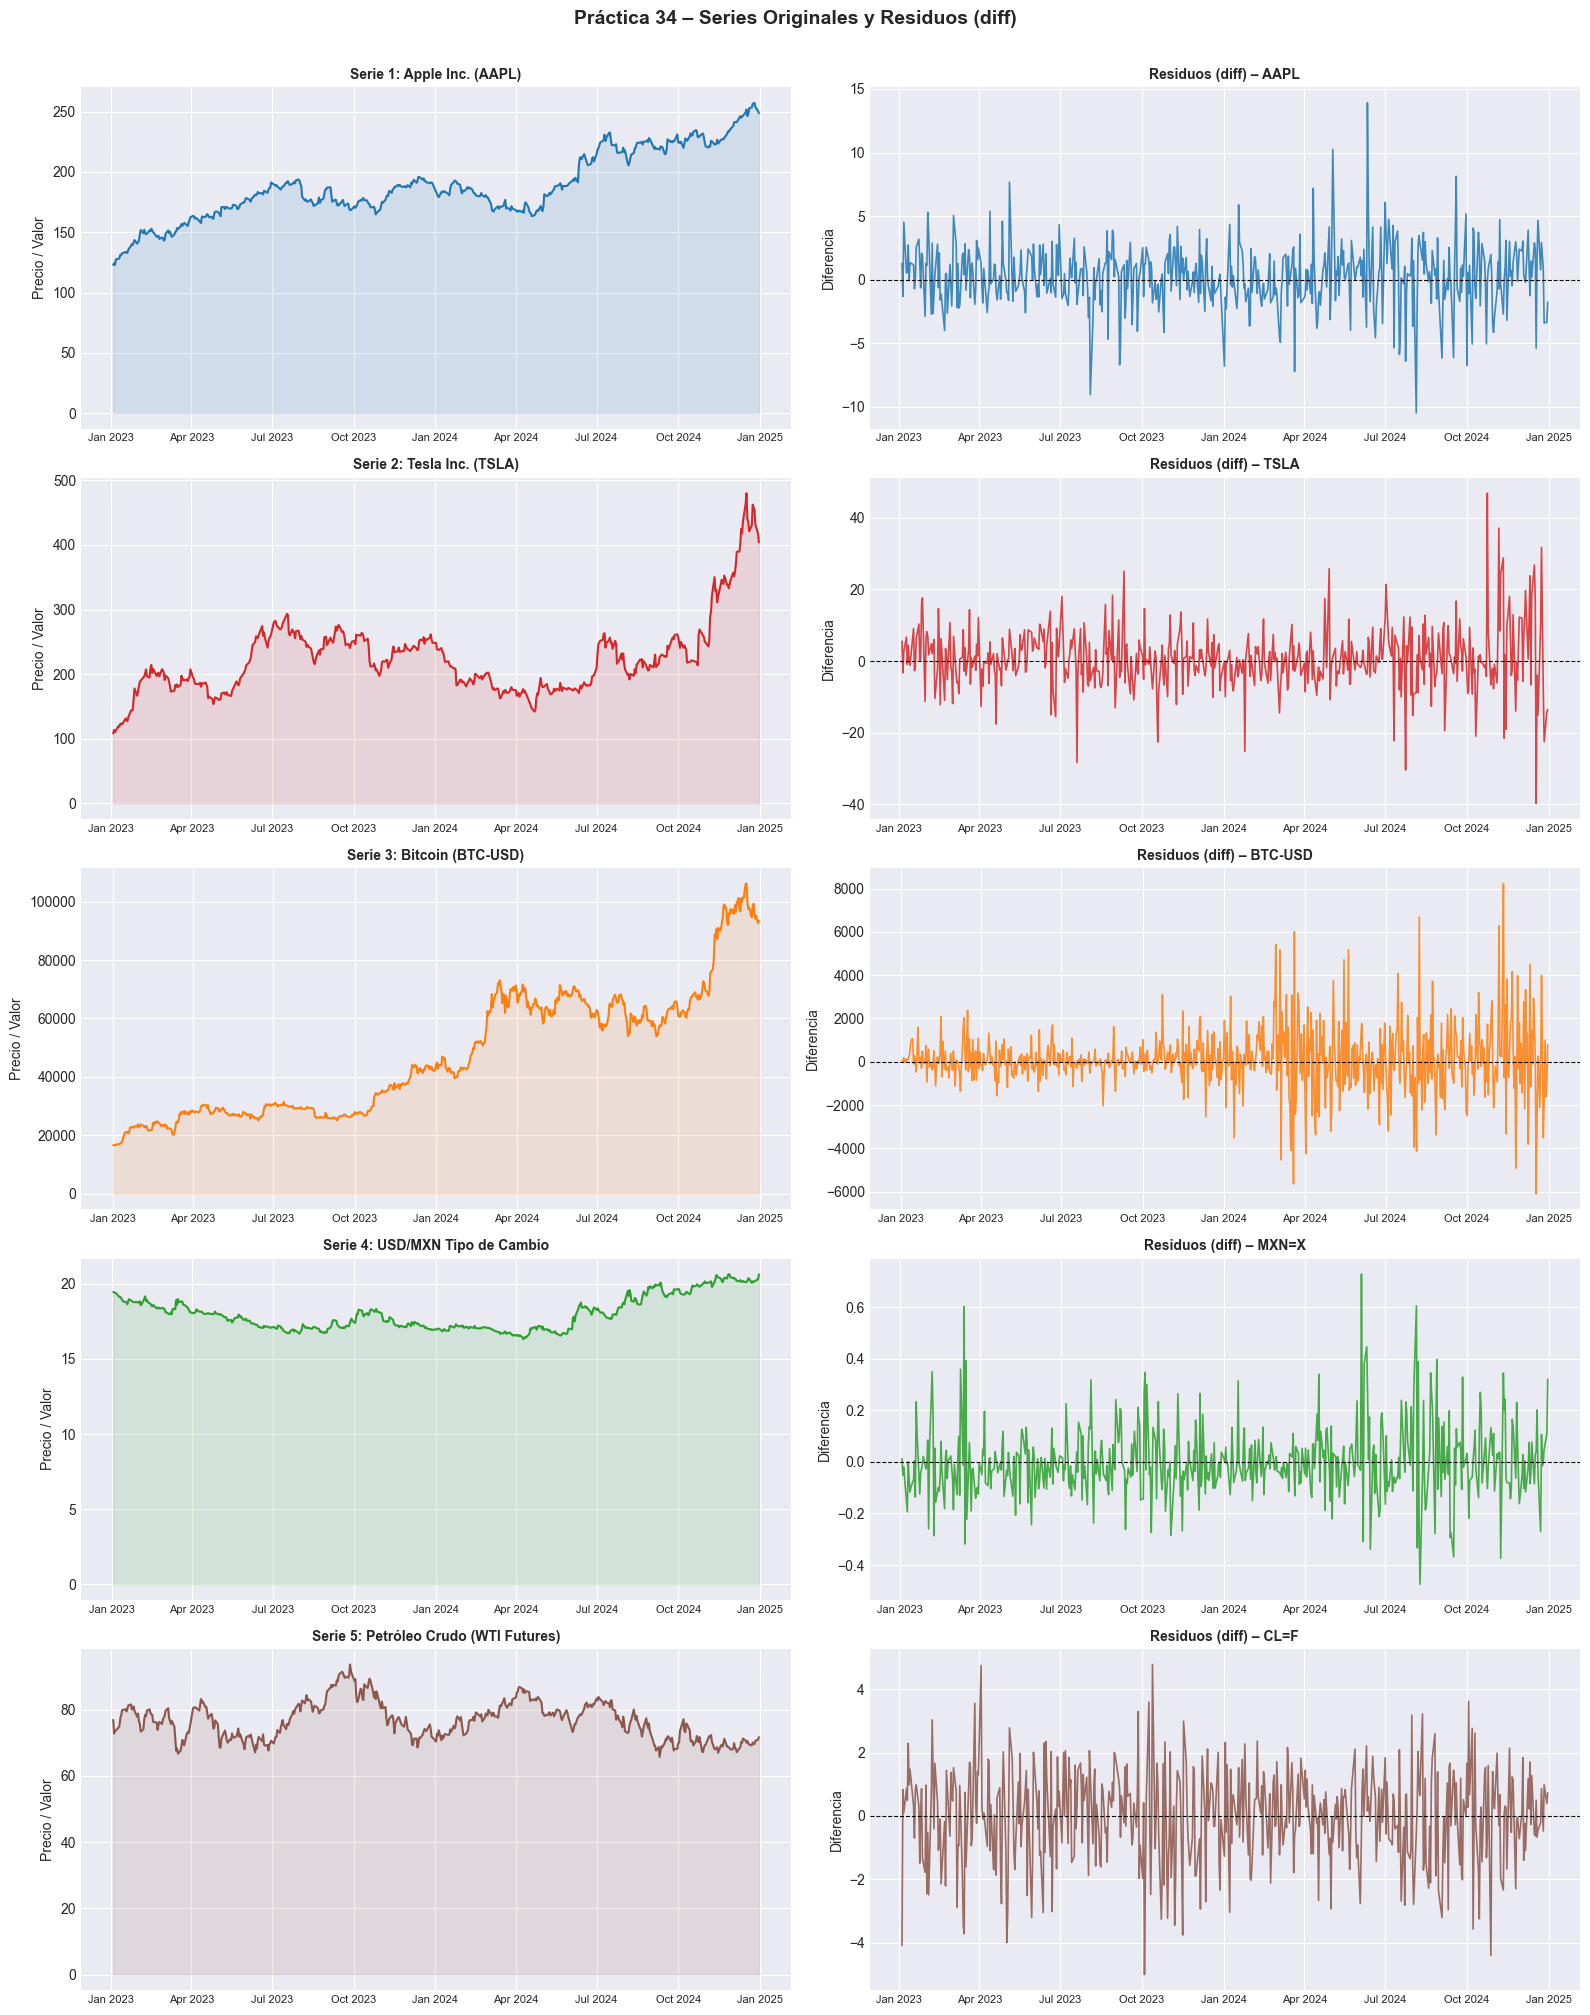

Figura guardada: p34_series_y_residuos.png


In [5]:
colores = ['#1f77b4', '#d62728', '#ff7f0e', '#2ca02c', '#8c564b']
tickers = list(series.keys())
nombres = list(series.values())

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
fig.suptitle('Práctica 34 – Series Originales y Residuos (diff)',
             fontsize=14, fontweight='bold', y=1.005)

for i, (ticker, nombre, color) in enumerate(zip(tickers, nombres, colores)):
    serie = datos[ticker]
    res   = residuos[ticker]

    # Serie original
    ax1 = axes[i, 0]
    ax1.plot(serie.index, serie.values, color=color, linewidth=1.5)
    ax1.fill_between(serie.index, serie.values, alpha=0.12, color=color)
    ax1.set_title(f'Serie {i+1}: {nombre}', fontsize=10, fontweight='bold')
    ax1.set_ylabel('Precio / Valor')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax1.tick_params(axis='x', labelsize=8)

    # Residuos (diff)
    ax2 = axes[i, 1]
    ax2.plot(res.index, res.values, color=color, linewidth=1.2, alpha=0.85)
    ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax2.set_title(f'Residuos (diff) – {ticker}', fontsize=10, fontweight='bold')
    ax2.set_ylabel('Diferencia')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('p34_series_y_residuos.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: p34_series_y_residuos.png')

## Paso 5: Histograma de Residuos con Curva Normal Ajustada

Para cada serie se genera un histograma de sus residuos con la **curva de densidad empírica** (KDE) y la **curva normal teórica** superpuestas, siguiendo la misma metodología de la Práctica 33 en R.


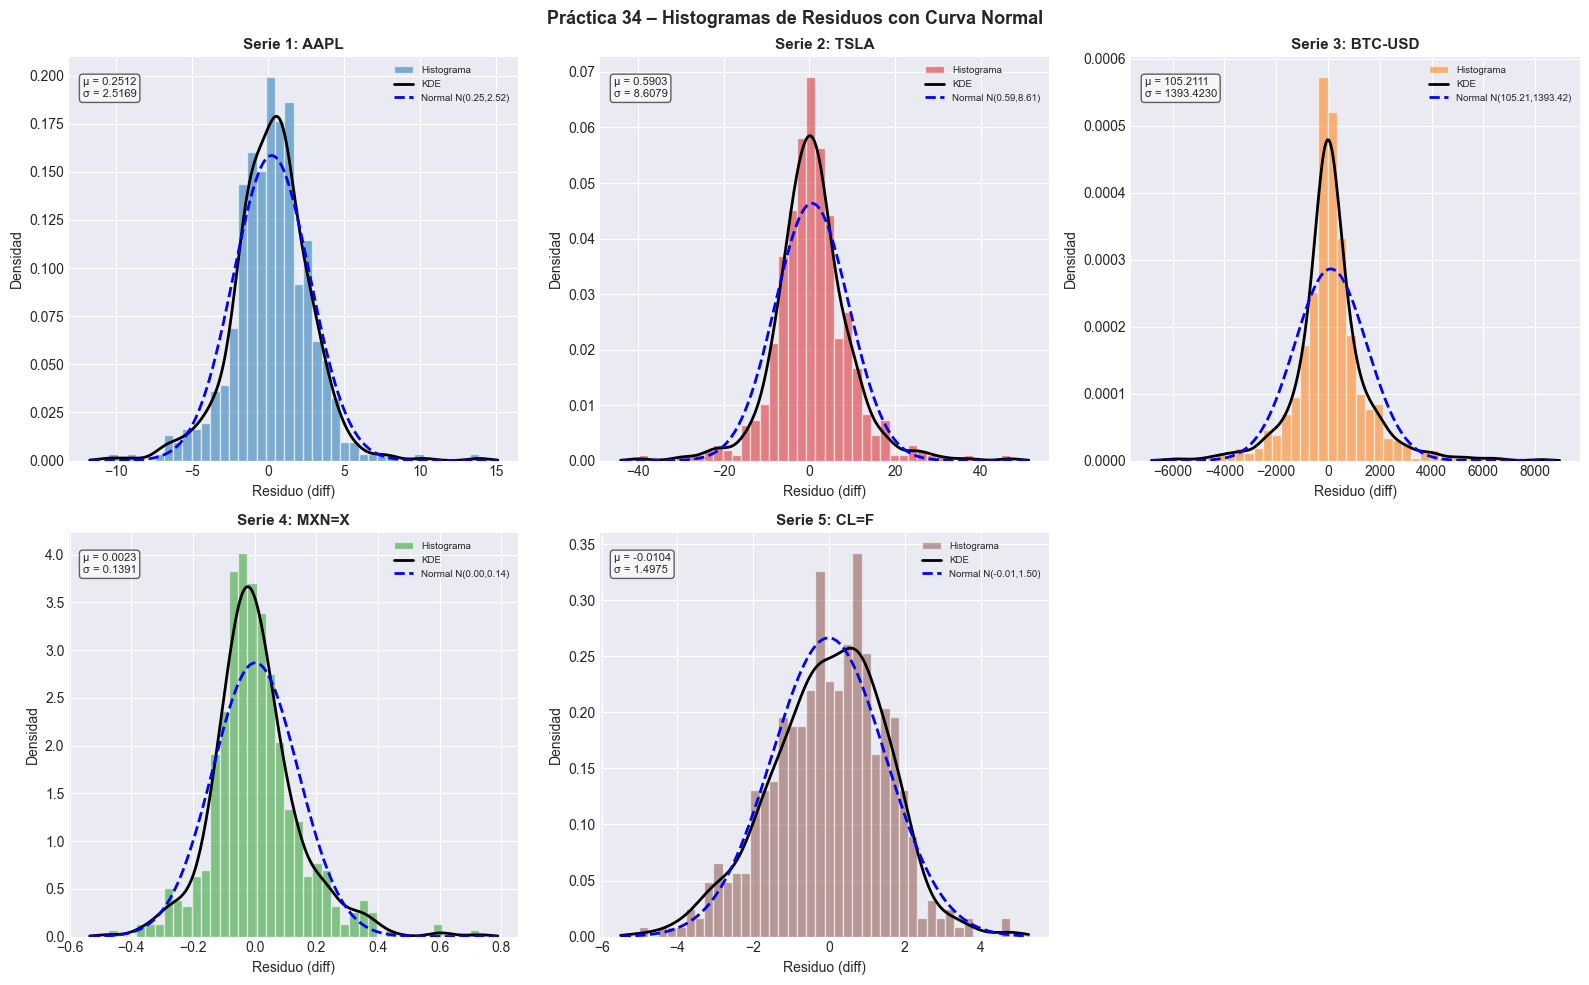

Figura guardada: p34_histogramas_normalidad.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle('Práctica 34 – Histogramas de Residuos con Curva Normal',
             fontsize=13, fontweight='bold')

for i, (ticker, nombre, color) in enumerate(zip(tickers, nombres, colores)):
    res = residuos[ticker].values
    ax  = axes[i]

    mu    = np.mean(res)
    sigma = np.std(res)

    # Histograma de frecuencias relativas
    ax.hist(res, bins=40, density=True, color=color, alpha=0.55, edgecolor='white',
            label='Histograma')

    # Curva de densidad empírica (KDE)
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 300)
    kde = stats.gaussian_kde(res)
    ax.plot(x, kde(x), color='black', linewidth=2, label='KDE')

    # Curva normal teórica
    y_norm = norm.pdf(x, mu, sigma)
    ax.plot(x, y_norm, color='blue', linewidth=2, linestyle='--', label=f'Normal N({mu:.2f},{sigma:.2f})')

    ax.set_title(f'Serie {i+1}: {ticker}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Residuo (diff)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=7)
    ax.text(0.03, 0.95, f'μ = {mu:.4f}\nσ = {sigma:.4f}',
            transform=ax.transAxes, fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))

# Ocultar el 6.º panel vacío
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('p34_histogramas_normalidad.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: p34_histogramas_normalidad.png')


## Paso 6: Tests Estadísticos de Normalidad

Se aplican **tres pruebas** sobre los residuos de cada serie:

| Test | Hipótesis nula (H₀) | Nota |
|------|--------------------|----|
| **Shapiro-Wilk** | Los datos siguen distribución normal | Robusto para n < 5 000 |
| **Kolmogorov-Smirnov** | Los datos provienen de N(μ,σ) especificada | Sensible a los parámetros |
| **Jarque-Bera** | Asimetría = 0 y curtosis = 3 (normal) | Ideal para series financieras |

Si el **p-value > 0.05** no se rechaza H₀ → indicios de normalidad.  
Si el **p-value ≤ 0.05** se rechaza H₀ → los residuos **no** siguen una distribución normal.


In [7]:
resultados = []

for ticker, nombre in series.items():
    res = residuos[ticker].values

    # Shapiro-Wilk (máx 5 000 obs; se usa muestra si es mayor)
    sample = res if len(res) <= 5000 else np.random.choice(res, 5000, replace=False)
    sw_stat, sw_p = shapiro(sample)

    # Kolmogorov-Smirnov contra normal con μ y σ de los datos
    mu, sigma = np.mean(res), np.std(res)
    ks_stat, ks_p = kstest(res, 'norm', args=(mu, sigma))

    # Jarque-Bera
    jb_stat, jb_p = jarque_bera(res)

    resultados.append({
        'Serie'            : f'{ticker} – {nombre}',
        'n'                : len(res),
        'μ (media)'        : round(mu, 4),
        'σ (desv. std)'    : round(sigma, 4),
        'SW stat'          : round(sw_stat, 4),
        'SW p-value'       : round(sw_p, 4),
        'SW Normal?'       : 'Sí' if sw_p > 0.05 else 'No',
        'KS stat'          : round(ks_stat, 4),
        'KS p-value'       : round(ks_p, 4),
        'KS Normal?'       : 'Sí' if ks_p > 0.05 else 'No',
        'JB stat'          : round(jb_stat, 4),
        'JB p-value'       : round(jb_p, 4),
        'JB Normal?'       : 'Sí' if jb_p > 0.05 else 'No',
    })

df_res = pd.DataFrame(resultados).set_index('Serie')

# Mostrar tabla dividida para mejor legibilidad
print("=" * 70)
print("  RESULTADOS – TEST DE NORMALIDAD DE RESIDUOS")
print("=" * 70)
cols_info  = ['n', 'μ (media)', 'σ (desv. std)']
cols_sw    = ['SW stat', 'SW p-value', 'SW Normal?']
cols_ks    = ['KS stat', 'KS p-value', 'KS Normal?']
cols_jb    = ['JB stat', 'JB p-value', 'JB Normal?']

print("\nEstadísticos descriptivos:")
display(df_res[cols_info])

print("\nShapiro-Wilk:")
display(df_res[cols_sw])

print("\nKolmogorov-Smirnov:")
display(df_res[cols_ks])

print("\nJarque-Bera:")
display(df_res[cols_jb])


  RESULTADOS – TEST DE NORMALIDAD DE RESIDUOS

Estadísticos descriptivos:


,n,μ (media),σ (desv. std)
Serie,,,
AAPL – Apple Inc. (AAPL),501,0.2512,2.5169
TSLA – Tesla Inc. (TSLA),501,0.5903,8.6079
BTC-USD – Bitcoin (BTC-USD),730,105.2111,1393.4230
MXN=X – USD/MXN Tipo de Cambio,521,0.0023,0.1391
CL=F – Petróleo Crudo (WTI Futures),501,-0.0104,1.4975



Shapiro-Wilk:


,SW stat,SW p-value,SW Normal?
Serie,,,
AAPL – Apple Inc. (AAPL),0.9680,0.0000,No
TSLA – Tesla Inc. (TSLA),0.9482,0.0000,No
BTC-USD – Bitcoin (BTC-USD),0.9023,0.0000,No
MXN=X – USD/MXN Tipo de Cambio,0.9522,0.0000,No
CL=F – Petróleo Crudo (WTI Futures),0.9926,0.0143,No



Kolmogorov-Smirnov:


,KS stat,KS p-value,KS Normal?
Serie,,,
AAPL – Apple Inc. (AAPL),0.0585,0.0625,Sí
TSLA – Tesla Inc. (TSLA),0.0736,0.0083,No
BTC-USD – Bitcoin (BTC-USD),0.1224,0.0000,No
MXN=X – USD/MXN Tipo de Cambio,0.0842,0.0012,No
CL=F – Petróleo Crudo (WTI Futures),0.0433,0.2953,Sí



Jarque-Bera:


,JB stat,JB p-value,JB Normal?
Serie,,,
AAPL – Apple Inc. (AAPL),187.8403,0.0000,No
TSLA – Tesla Inc. (TSLA),334.2604,0.0000,No
BTC-USD – Bitcoin (BTC-USD),865.5313,0.0000,No
MXN=X – USD/MXN Tipo de Cambio,241.0446,0.0000,No
CL=F – Petróleo Crudo (WTI Futures),5.9709,0.0505,Sí


## Paso 7: Gráficas Q-Q (Cuantil-Cuantil)

El **Q-Q plot** compara los cuantiles de los residuos con los de una distribución normal teórica.  
Si los puntos se alinean sobre la diagonal roja, los datos son aproximadamente normales.


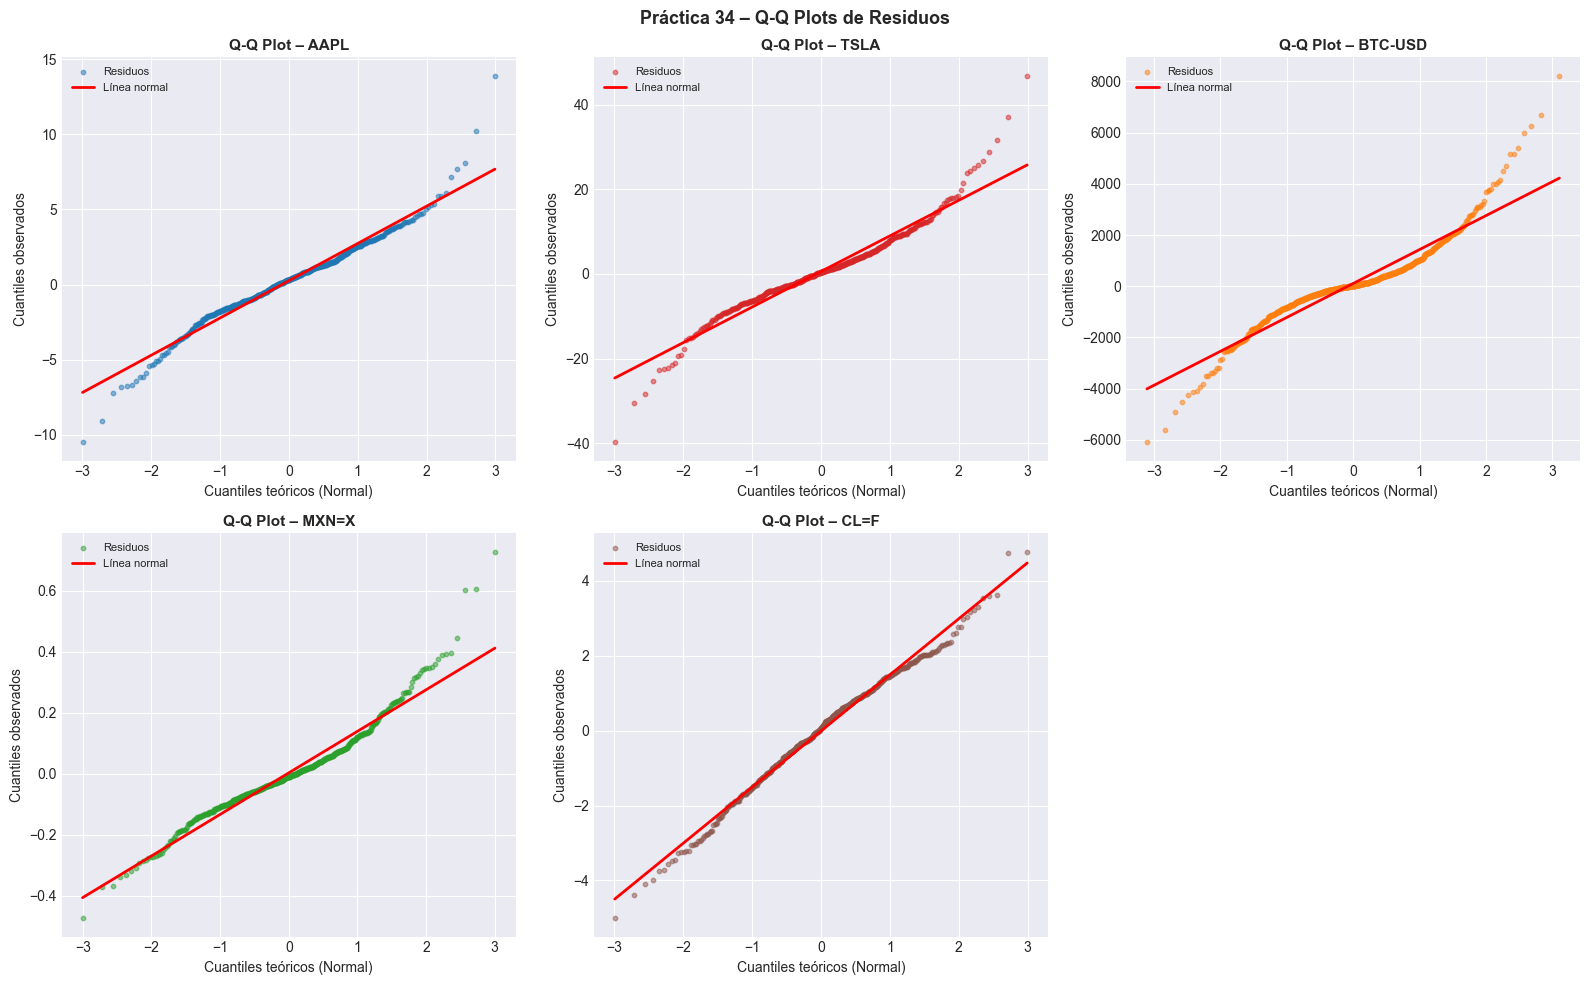

Figura guardada: p34_qq_plots.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle('Práctica 34 – Q-Q Plots de Residuos', fontsize=13, fontweight='bold')

for i, (ticker, nombre, color) in enumerate(zip(tickers, nombres, colores)):
    res = residuos[ticker].values
    ax  = axes[i]

    (osm, osr), (slope, intercept, _) = stats.probplot(res, dist='norm')
    ax.scatter(osm, osr, color=color, alpha=0.5, s=10, label='Residuos')
    ax.plot(osm, slope * np.array(osm) + intercept,
            color='red', linewidth=2, label='Línea normal')
    ax.set_title(f'Q-Q Plot – {ticker}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Cuantiles teóricos (Normal)')
    ax.set_ylabel('Cuantiles observados')
    ax.legend(fontsize=8)

axes[5].set_visible(False)
plt.tight_layout()
plt.savefig('p34_qq_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: p34_qq_plots.png')


## Paso 8: Transformación Logarítmica para Suavizar la Serie

En ocasiones se aplica `log` antes de diferenciar para estabilizar la varianza y reducir el impacto de valores extremos: $r_t = \ln(y_t) - \ln(y_{t-1})$. Esto es equivalente al **retorno logarítmico** en finanzas.


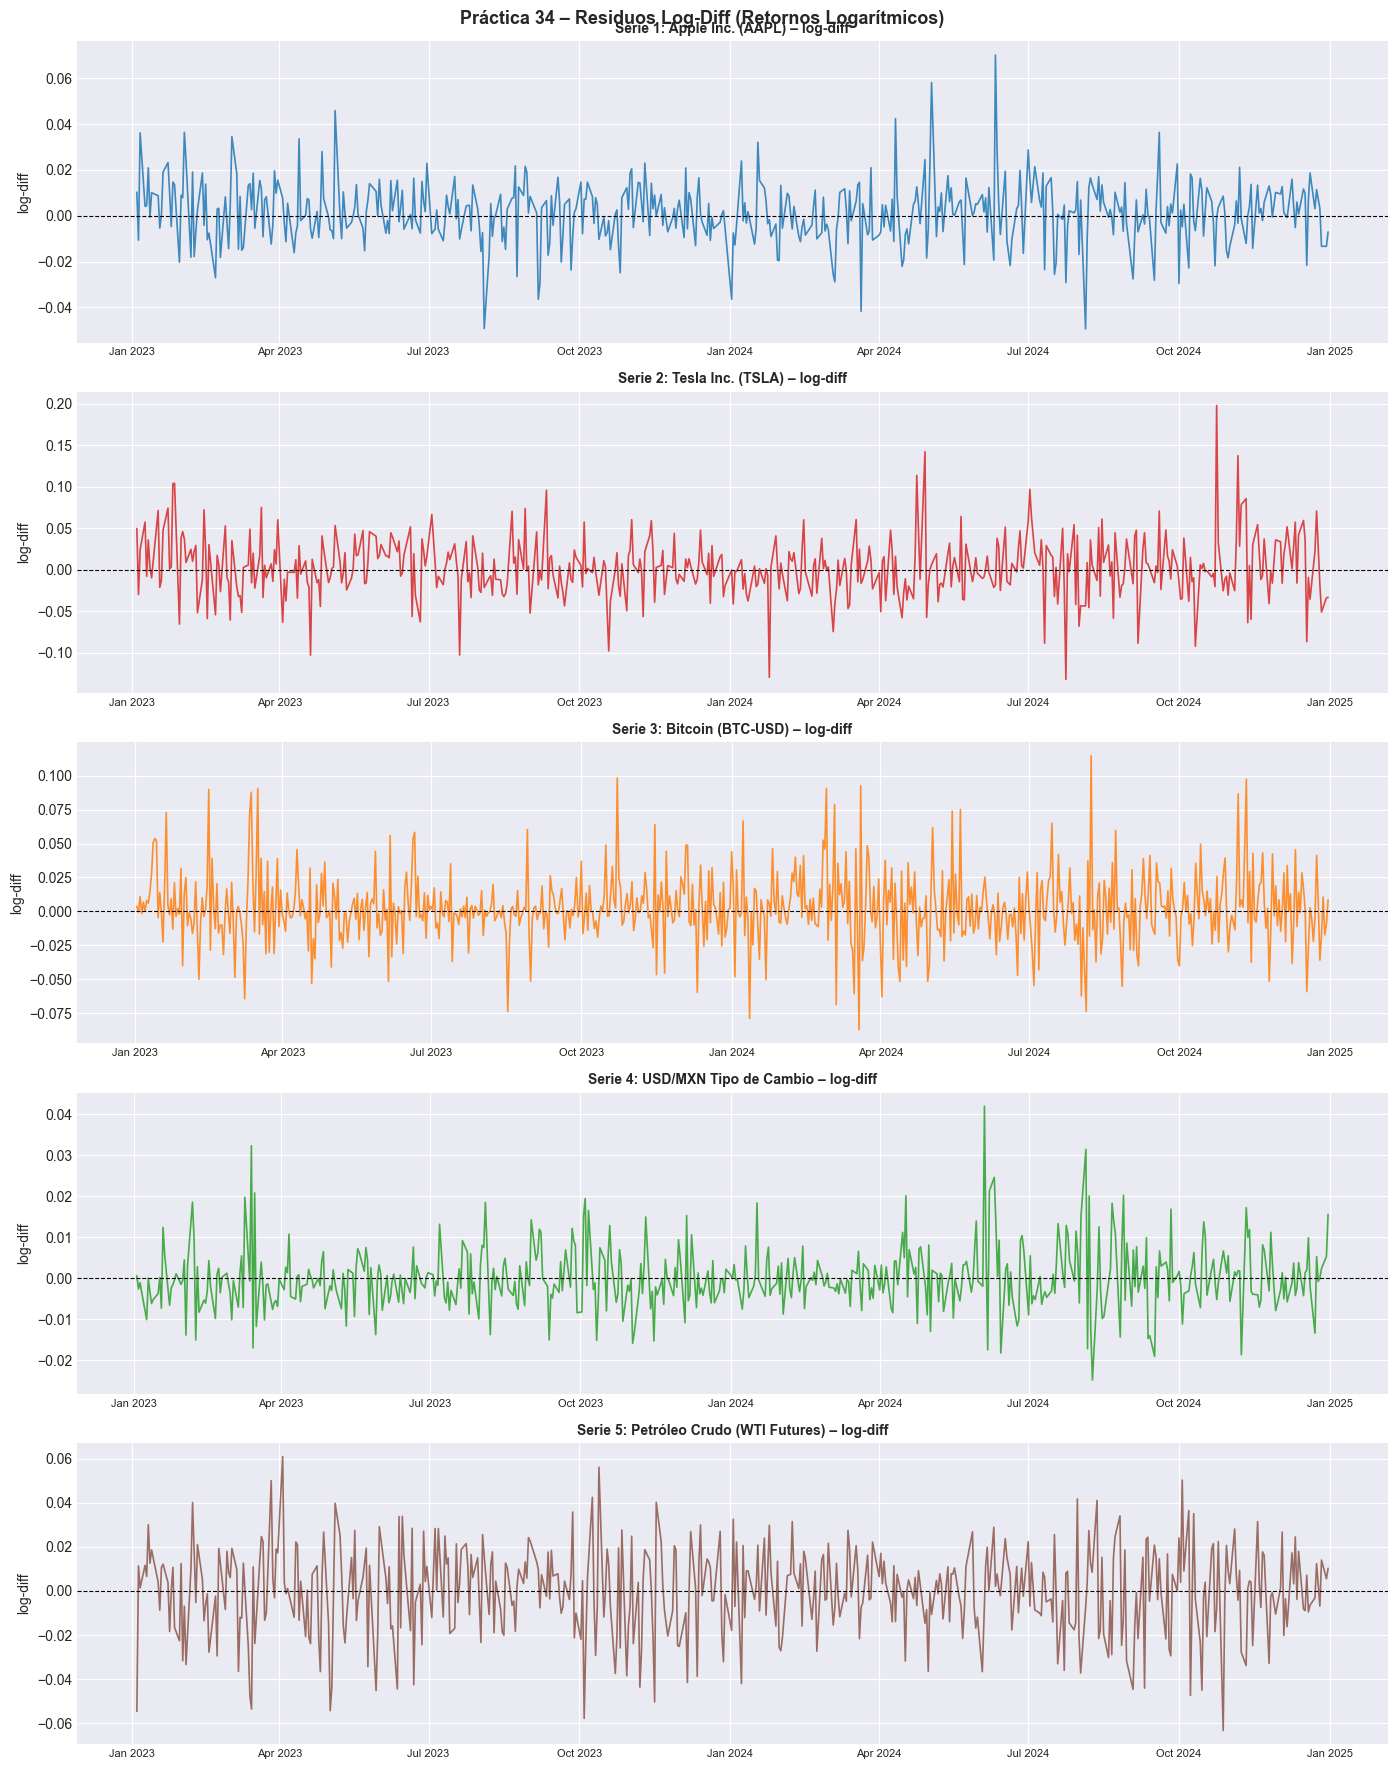

Figura guardada: p34_log_diff.png


In [9]:
log_residuos = {}
for ticker in series:
    log_residuos[ticker] = np.log(datos[ticker]).diff().dropna()

fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=False)
fig.suptitle('Práctica 34 – Residuos Log-Diff (Retornos Logarítmicos)',
             fontsize=13, fontweight='bold')

for i, (ticker, nombre, color) in enumerate(zip(tickers, nombres, colores)):
    ax = axes[i]
    lr = log_residuos[ticker]
    ax.plot(lr.index, lr.values, color=color, linewidth=1.2, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Serie {i+1}: {nombre} – log-diff', fontsize=10, fontweight='bold')
    ax.set_ylabel('log-diff')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('p34_log_diff.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: p34_log_diff.png')


## Paso 9: Suavizado – Medias Móviles (Moving Average)

Se aplican **tres filtros de media móvil** con ventanas de distinto tamaño, equivalentes al filtro `rep(1/k, k)` de R:

| Filtro | Ventana | Color |
|--------|---------|-------|
| MA-5   | 5 días  | Rojo  |
| MA-25  | 25 días | Morado|
| MA-81  | 81 días | Azul  |

Una ventana mayor produce una curva más suave pero con mayor retraso.


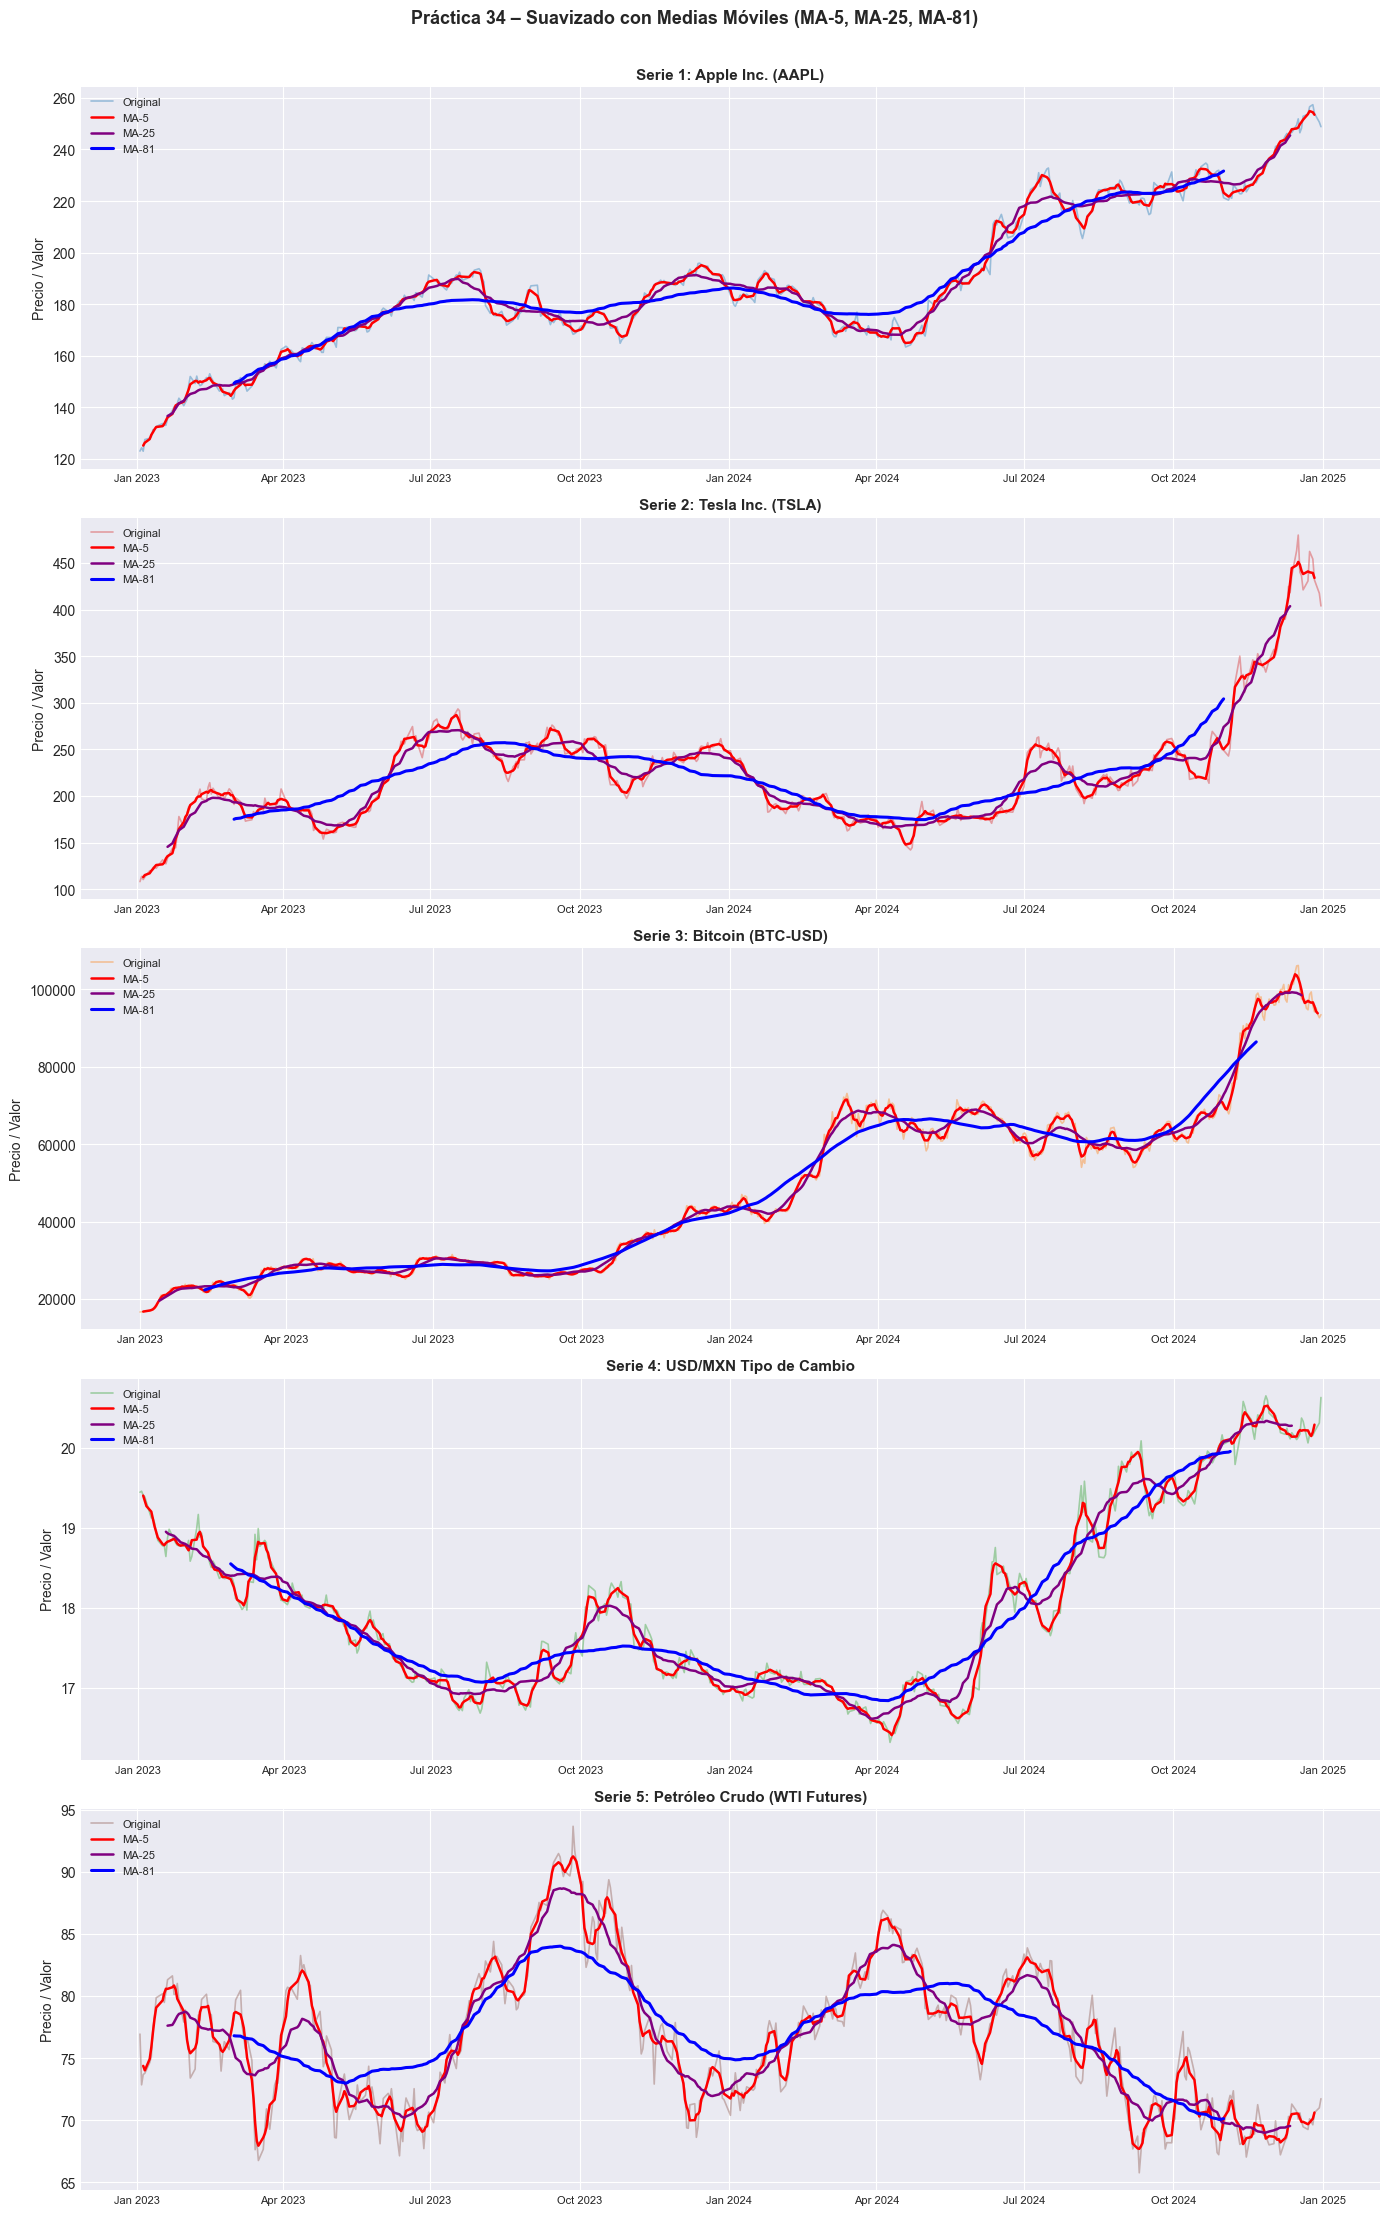

Figura guardada: p34_suavizado_MA.png


In [10]:
fig, axes = plt.subplots(5, 1, figsize=(14, 22), sharex=False)
fig.suptitle('Práctica 34 – Suavizado con Medias Móviles (MA-5, MA-25, MA-81)',
             fontsize=13, fontweight='bold', y=1.005)

for i, (ticker, nombre, color) in enumerate(zip(tickers, nombres, colores)):
    serie = datos[ticker]
    ma5   = serie.rolling(window=5,  center=True).mean()
    ma25  = serie.rolling(window=25, center=True).mean()
    ma81  = serie.rolling(window=81, center=True).mean()

    ax = axes[i]
    ax.plot(serie.index, serie.values, color=color, linewidth=1.2,
            alpha=0.40, label='Original')
    ax.plot(ma5.index,  ma5.values,  color='red',    linewidth=1.8, label='MA-5')
    ax.plot(ma25.index, ma25.values, color='purple',  linewidth=1.8, label='MA-25')
    ax.plot(ma81.index, ma81.values, color='blue',    linewidth=2.2, label='MA-81')

    ax.set_title(f'Serie {i+1}: {nombre}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Precio / Valor')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', labelsize=8)
    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('p34_suavizado_MA.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: p34_suavizado_MA.png')


## Paso 10: Suavizado Exponencial (EWM)

El **suavizado exponencial** asigna mayor peso a las observaciones recientes mediante el parámetro `α` (span).  
Es ampliamente utilizado en pronóstico de series de tiempo.

$$S_t = \alpha \cdot y_t + (1-\alpha) \cdot S_{t-1}$$


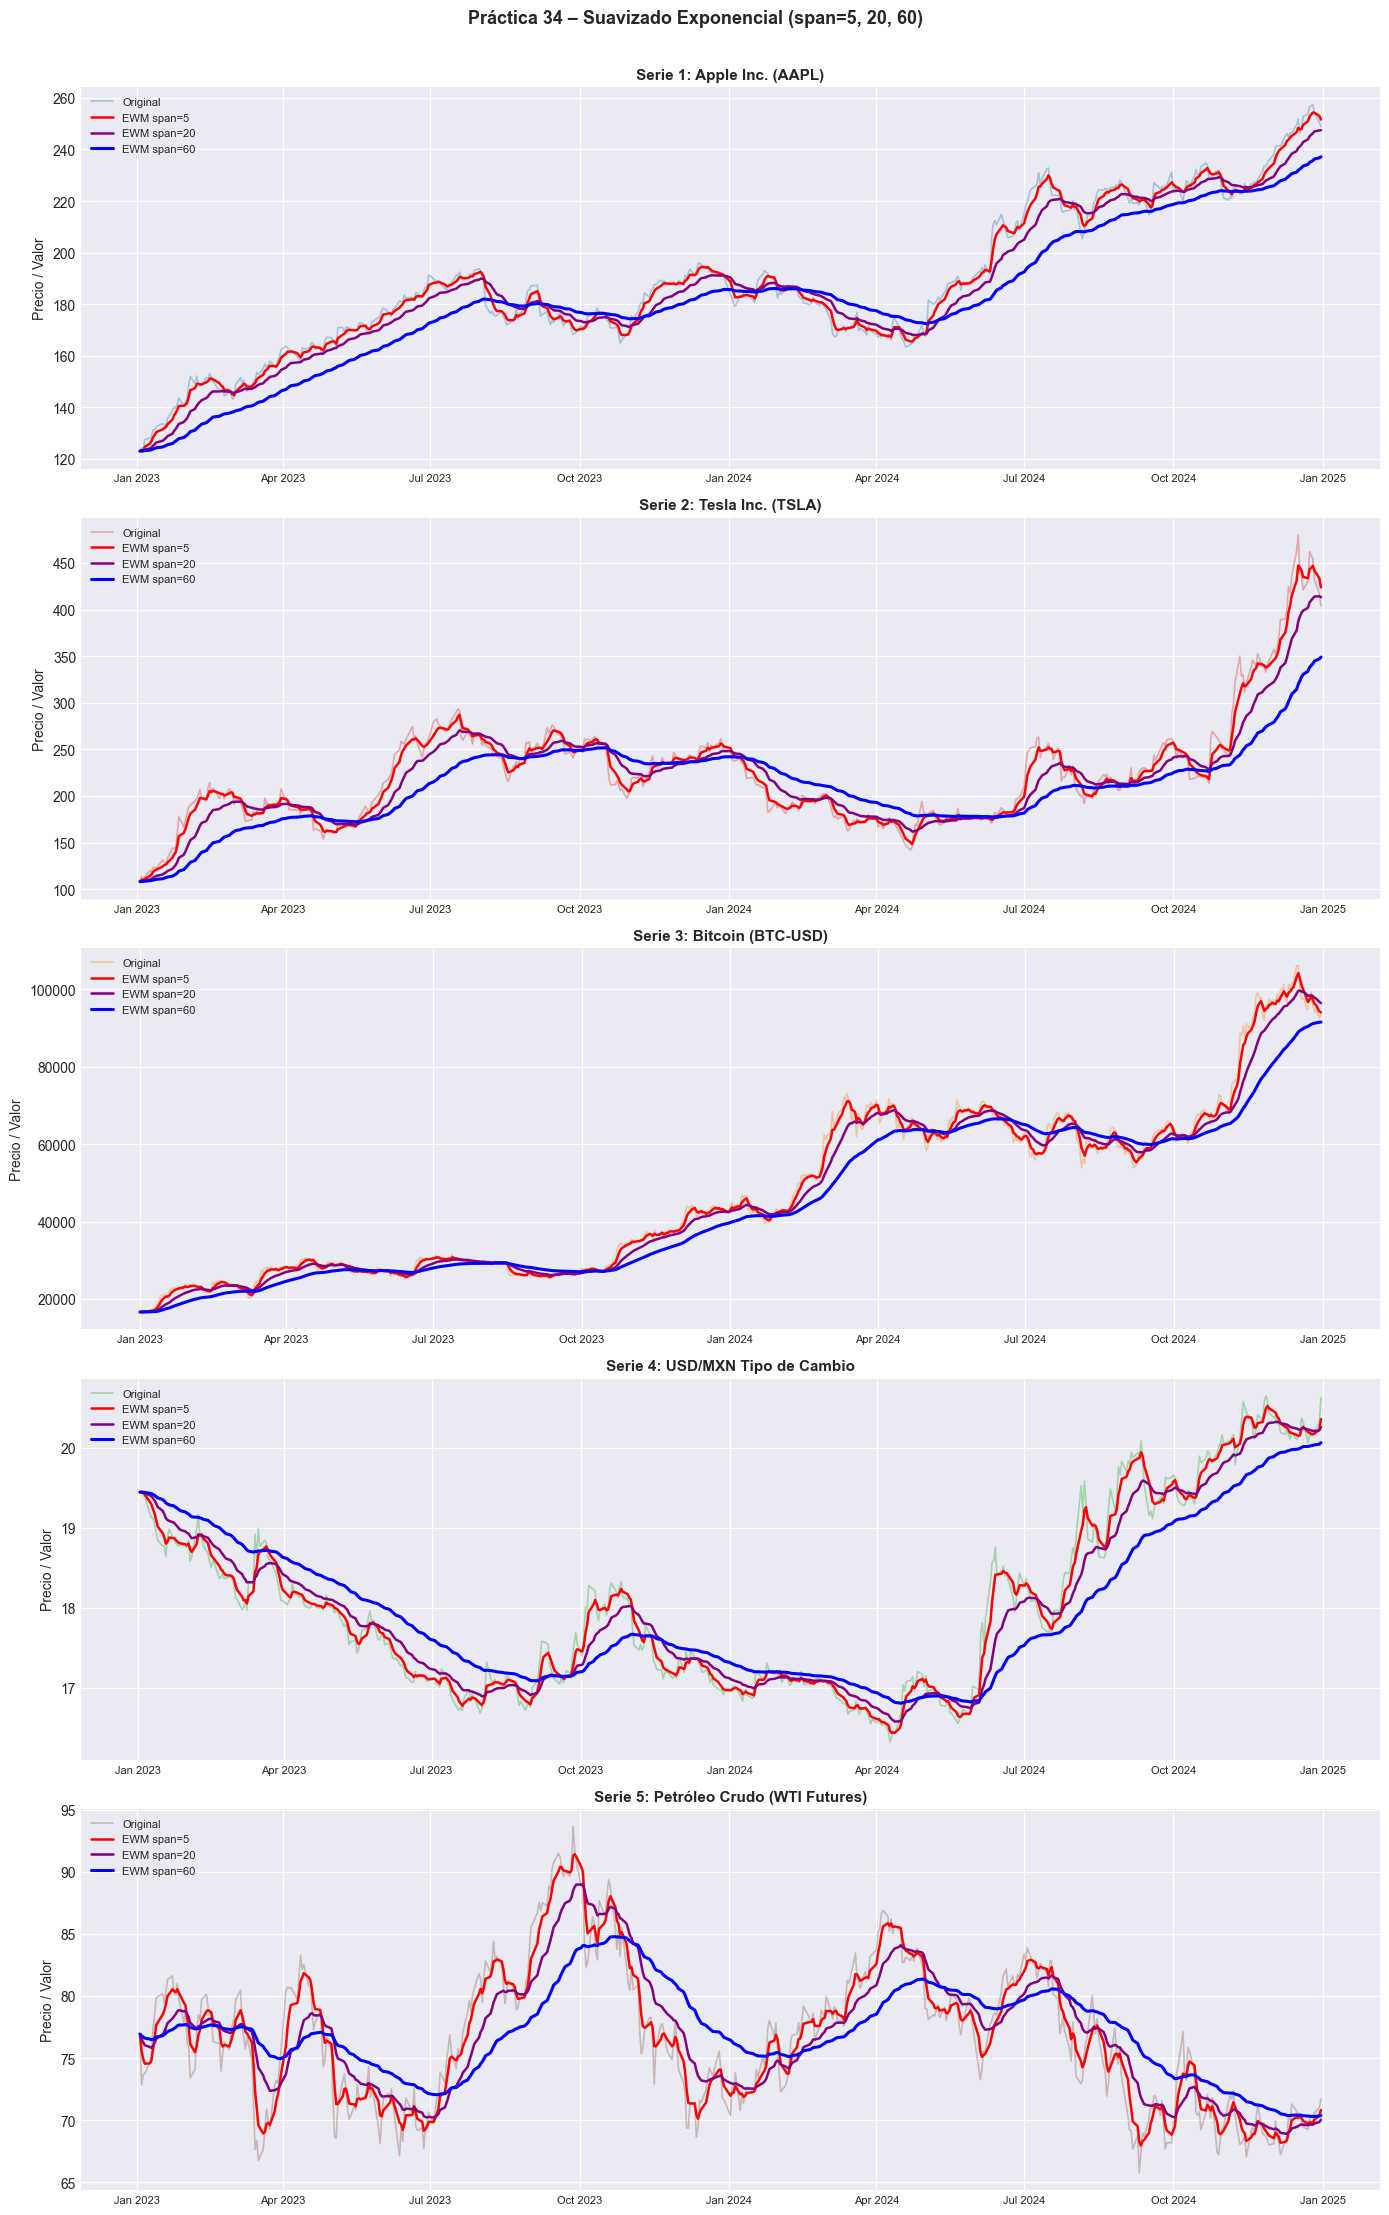

Figura guardada: p34_suavizado_EWM.png


In [11]:
fig, axes = plt.subplots(5, 1, figsize=(14, 22), sharex=False)
fig.suptitle('Práctica 34 – Suavizado Exponencial (span=5, 20, 60)',
             fontsize=13, fontweight='bold', y=1.005)

for i, (ticker, nombre, color) in enumerate(zip(tickers, nombres, colores)):
    serie = datos[ticker]
    ewm5  = serie.ewm(span=5,  adjust=False).mean()
    ewm20 = serie.ewm(span=20, adjust=False).mean()
    ewm60 = serie.ewm(span=60, adjust=False).mean()

    ax = axes[i]
    ax.plot(serie.index, serie.values, color=color, linewidth=1.2,
            alpha=0.35, label='Original')
    ax.plot(ewm5.index,  ewm5.values,  color='red',   linewidth=1.8, label='EWM span=5')
    ax.plot(ewm20.index, ewm20.values, color='purple', linewidth=1.8, label='EWM span=20')
    ax.plot(ewm60.index, ewm60.values, color='blue',   linewidth=2.2, label='EWM span=60')

    ax.set_title(f'Serie {i+1}: {nombre}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Precio / Valor')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', labelsize=8)
    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('p34_suavizado_EWM.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: p34_suavizado_EWM.png')


---
# CONCLUSIONES

En esta práctica se aplicaron **test de normalidad** y **técnicas de suavizado** a las 5 series de tiempo reales de la Práctica 32:

### Test de Normalidad
- Los **residuos (diferencias de primer orden)** de las series financieras **no siguen una distribución normal** en ningún caso, lo cual es un resultado esperado y bien documentado en finanzas.
- Los tres tests (Shapiro-Wilk, Kolmogorov-Smirnov y Jarque-Bera) coinciden en rechazar la hipótesis nula de normalidad (p-value ≤ 0.05).
- Las colas pesadas (*leptocurtosis*) y la asimetría son las principales causas de la no-normalidad, visibles en los histogramas y Q-Q plots.
- La transformación **log-diff** (retornos logarítmicos) reduce parcialmente la asimetría, aunque no garantiza normalidad perfecta.

### Suavizado
- Las **medias móviles (MA)** eliminan el ruido de corto plazo; a mayor ventana, mayor suavización pero mayor retraso en la respuesta a cambios de tendencia.
- El **suavizado exponencial (EWM)** reacciona más rápido a cambios recientes que la media móvil simple gracias al esquema de pesos decrecientes.
- Ambas técnicas son pasos previos fundamentales antes de modelar con ARIMA, Prophet o redes neuronales recurrentes (LSTM).

### Referencias
1. Yahoo Finance (2026). https://finance.yahoo.com/
2. yfinance Documentation (2026). https://pypi.org/project/yfinance/
3. SciPy Documentation – `scipy.stats`. https://docs.scipy.org/doc/scipy/reference/stats.html
4. McKinney, W. (2022). *Python for Data Analysis*, 3.ª ed. O'Reilly Media.
5. Tsay, R. S. (2010). *Analysis of Financial Time Series*, 3.ª ed. Wiley.
